In [49]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.nn.functional import interpolate

from datasets import load_dataset
from inpaintingStart import *
import argparse

from PIL import Image
import gradio as gr
from imagenet_en_cn import IMAGENET_1K_CLASSES
from omegaconf import OmegaConf

import torch
from transformers import T5EncoderModel, AutoTokenizer

from pixelflow.scheduling_pixelflow import PixelFlowScheduler
from pixelflow.pipeline_pixelflow import PixelFlowPipeline
from pixelflow.utils import config as config_utils
from pixelflow.utils.misc import seed_everything

from sampler2 import PixelFlowPipeline3
import time
import matplotlib.pyplot as plt
import imageio
import math
import copy
from pathlib import Path
from einops import rearrange
# ds = load_dataset("ILSVRC/imagenet-1k")

In [ ]:
data_dir = '/home/../mnt/data3/ruy45/dataset/imageNet256/ILSVRC/Data/CLS-LOC/train/'

def center_crop_arr(pil_image, image_size):
    while min(*pil_image.size) >= 2 * image_size:
        pil_image = pil_image.resize(
            tuple(x // 2 for x in pil_image.size), resample=Image.BOX
        )

    scale = image_size / min(*pil_image.size)
    pil_image = pil_image.resize(
        tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC
    )

    arr = np.array(pil_image)
    crop_y = (arr.shape[0] - image_size) // 2
    crop_x = (arr.shape[1] - image_size) // 2
    return Image.fromarray(arr[crop_y: crop_y + image_size, crop_x: crop_x + image_size])

transform = transforms.Compose([
    transforms.Lambda(lambda pil_image: center_crop_arr(pil_image, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True)])
dataset = ImageFolder(data_dir, transform=transform)

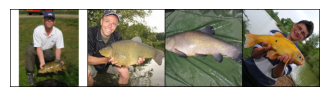

In [3]:
loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=False, num_workers=4)
imgs, labels = next(iter(loader))      # imgs: [B,3,256,256] in [-1,1]
imgs_vis = (imgs * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(imgs_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

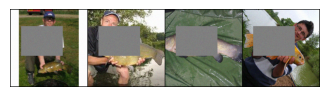

In [4]:
sigma_n =0.05
A_opr = op = get_operator(
        "inpainting",
        mask_type='box',
        mask_len_range=(80, 160),
        mask_prob_range=None,
        resolution=256,
        device='cpu',
        sigma=sigma_n,
    )
y = A_opr.measure(imgs)
y_vis = (y * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [110]:
seed_everything(20000120)
num_stages = 4 # config.scheduler.num_stages
inference_each_step = 10
class_label = 1000
NUM_EXAMPLES = 16
resolution = 256
num_Langevin = 100
sigma_n =0.05
shift = 1.0
proj = True
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
output_dir = './pretrained_models/c2img'
A_opr = get_operator("inpainting", mask_type='box', mask_len_range=(80, 160), mask_prob_range=None, resolution=resolution, device=device, sigma=sigma_n)
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
config = OmegaConf.load(f"{output_dir}/config.yaml")
model = config_utils.instantiate_from_config(config.model).to(device)
print(f"Num of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
ckpt = torch.load(f"{output_dir}/model.pt", map_location="cpu", weights_only=False)
model.load_state_dict(ckpt, strict=True)
model.eval()
text_encoder = None
tokenizer = None
scheduler = PixelFlowScheduler(config.scheduler.num_train_timesteps, num_stages=config.scheduler.num_stages, gamma=-1/3)
scheduler_copy = copy.deepcopy(scheduler)
sampler_pipeline = PixelFlowPipeline3(scheduler_copy,model,text_encoder=text_encoder,tokenizer=tokenizer, max_token_length=512,)

Starting Initialization...
Num of parameters: 676611120


In [100]:
def sample_block_noise(scheduler, bs, ch, height, width, eps=1e-6):
    gamma = scheduler.gamma
    dist = torch.distributions.multivariate_normal.MultivariateNormal(torch.zeros(4), torch.eye(4) * (1 - gamma) + torch.ones(4, 4) * gamma + eps * torch.eye(4))
    block_number = bs * ch * (height // 2) * (width // 2)
    noise = torch.stack([dist.sample() for _ in range(block_number)]) # [block number, 4]
    noise = rearrange(noise, '(b c h w) (p q) -> b c (h p) (w q)',b=bs,c=ch,h=height//2,w=width//2,p=2,q=2)
    return noise
def T_to_t_linear(Timesteps, t, T):
    T_end = Timesteps[-1]
    T_start = Timesteps[0]
    t_end = t[-2]
    t_start = t[0]
    k = (T_end - T_start) / (t_end - t_start)
    b = T_start - t_start * k
    return (T-b)/k
def get_xt_from_x0(scheduler, Timesteps, x0, stage_idx, T, stage_noise = None, last_stage_xt = None, renoise = False):
    # When you set last_stage_xt = None, you do interpolate. If it is the x_end_{k+1}, then you get x_start_{k} by renoising.
    if stage_idx >0 and T == scheduler.Timesteps_per_stage[stage_idx][0] and renoise:
        print(f"New stage renoising! T = {T}, stage = {stage_idx}.")
        assert last_stage_xt != None, f"You need to input x_e_{stage_idx} to get x_s_{stage_idx+1}"
        xt = last_stage_xt
        height, width = xt.shape[-2],xt.shape[-1]
        height, width = height * 2, width * 2
        xt = F.interpolate(xt, size=(height, width), mode='nearest')
        original_start_t = scheduler.original_start_t[stage_idx]
        gamma = scheduler.gamma
        alpha = 1 / (math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t)
        beta = alpha * (1 - original_start_t) / math.sqrt(- gamma)

        noise = sample_block_noise(scheduler, *xt.shape)
        noise = noise.to(device=device, dtype=xt.dtype)
        xt = alpha * xt + beta * noise
        return xt
    else:
        start_t, end_t = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
        print(f"Start T: {start_t}")
        resolution = x0.shape[-1]
        pixel_values_end = x0
        pixel_values_start = x0
        if stage_idx < num_stages - 1:
            # pixel_values_end
            for downsample_idx in range(1, num_stages - stage_idx):
                pixel_values_end = F.interpolate(pixel_values_end, (resolution // (2 ** downsample_idx), resolution // (2 ** downsample_idx)), mode="bilinear")

            # pixel_values_start
        
        for downsample_idx in range(1, num_stages - stage_idx + 1):
            pixel_values_start = F.interpolate(pixel_values_start, (resolution // (2 ** downsample_idx), resolution // (2 ** downsample_idx)), mode="bilinear")
        # upsample pixel_values_start
        end_height, end_width = pixel_values_end.shape[-1], pixel_values_end.shape[-2]
        pixel_values_start = F.interpolate(pixel_values_start, (end_height, end_width), mode="nearest")

        if stage_noise == None: 
            noise = torch.randn_like(pixel_values_end)
        else:
            noise = stage_noise
        pixel_values_end = end_t * pixel_values_end + (1.0 - end_t) * noise
        # print(pixel_values_end.shape, pixel_values_start.shape, noise.shape)
        pixel_values_start = start_t * pixel_values_start + (1.0 - start_t) * noise

        # Ts = scheduler.Timesteps_per_stage[stage_idx].to(torch.float64)
        # k = int(torch.argmin(torch.abs(Ts - T)).item())              # nearest index
        # t_select = torch.tensor(scheduler.t_window_per_stage[stage_idx][k].item(), dtype = torch.float32, device = device) 
        t_select = T_to_t_linear(Timesteps, scheduler.t, T).to(device)
        xt = t_select.float() * pixel_values_end.to(device) + (1.0 - t_select.float()) * pixel_values_start.to(device)
        # print(start_t, end_t, T, t_select)
        return xt
    

In [101]:
def get_stage_noise(coarse_noise):
    # coarse: nearest upsample then normalize the block-constant basis
    coarse = F.interpolate(coarse_noise, scale_factor=2, mode="nearest") / 2.0
    addition = torch.randn_like(coarse)

    # subtract 2x2 block mean -> enforce sum-zero per block (project to orthogonal complement)
    block_mean = F.avg_pool2d(addition, kernel_size=2, stride=2)                 # (B,C,32,32)
    block_mean_up = F.interpolate(block_mean, scale_factor=2, mode="nearest")  # (B,C,64,64)
    noise_orth = addition - block_mean_up

    stage_noise = coarse + noise_orth
    return stage_noise

In [ ]:
@torch.no_grad()
def langevin_update(
    x: torch.Tensor,
    operator,
    y: torch.Tensor,
    x0hat: torch.Tensor,      
    sigma_n: float,          
    T: float, #inference_step           
    step_size: float, 
    device
):
    x = x.to(device)
    y = y.to(device)
    """
    One step overdamped Langevin for p(x) ∝ exp(-L(x)).
    L(x) = 1/(2σ_n^2)||Hx-y||^2 + 1/(2ν_t^2)||x-x1hat||^2
    """
    def nu_t(T):
        nt = T/1000
        # return 1-nt
        return (1 - nt)/math.sqrt(nt**2 + (1 - nt)**2)
    # ∇||Hx - y||^2  (operator.gradient 内部会用 autograd)
    with torch.enable_grad():
        x = x.detach().requires_grad_(True)
        grad_data_sq = operator.gradient(x, y)
        # grad_data_sq = torch.autograd.grad(((operator.measure(x) -y)**2/(2*sigma_n**2)).sum(), x)[0]
        grad_loss = (x-x0hat)**2 / (2*nu_t(T)**2 + 1e-4)
        grad_prior = torch.autograd.grad(grad_loss.sum(), x)[0]
    grad_data = grad_data_sq / (2.0 * (sigma_n ** 2))  # => (1/σ_n^2) H^T(Hx-y)
    # print(grad_data_sq.norm(), grad_prior.norm())
    # grad_data = grad_data_sq / (2.0 * (sigma_n ** 2)) 

    # ∇ 1/(2ν_t^2)||x - x0hat||^2
    # grad_prior = (x - x0hat) / (nu_t(T) ** 2 + 1e-4)

    grad_L = grad_data + grad_prior

    eps = torch.randn_like(x)
    x_new = x - step_size * grad_L + math.sqrt(2.0 * step_size) * eps
    return x_new

def langevin_sample(
    x_init, operator, y, x0hat,
    sigma_n, T,
    step_size=1e-4, num_steps=50,
    device = 'cpu',
    proj = False
):
    if proj:
        o_M = operator.mask.to(device)
    else:
        o_M = torch.zeros_like(y, device=device)
    x = x_init.clone().detach()
    for _ in range(num_steps):
        # x = langevin_update(x, operator, y, x0hat, sigma_n, T, step_size, device)
        x = (1-o_M)*langevin_update(x, operator, y, x0hat, sigma_n, T, step_size, device) + o_M*y
        if torch.isnan(x).any():
            break
    return x.detach()

def get_lr(ratio, lr_base = 1e-4, lr_min_ratio = 0.01):
    p = 1
    multiplier = (1 ** (1 / p) + ratio * (lr_min_ratio ** (1 / p) - 1 ** (1 / p))) ** p
    return multiplier * lr_base


In [103]:
seed_everything(20000120)
idx = torch.randperm(len(dataset))[:NUM_EXAMPLES]
gt = torch.stack([dataset[i][0] for i in idx], dim=0) 
labels = [dataset[i][1] for i in idx]
y = A_opr.measure(gt).to(device)

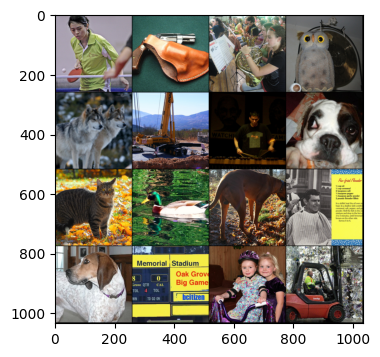

In [104]:
xt_vis = (gt.float() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(xt_vis.cpu(), nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))

In [105]:
def inverseSample(y, operator, num_stages, inference_each_step, ode_steps_per_stage, langevin_steps, 
                  Langevin_proj, resolution, device, return_traj = True, fix_stage_noise = False, renoise = False, 
                  guidance=0., lr_base = 1e-3,lr_min_ratio = 1e-2):
    from tqdm.auto import tqdm
    x0_hats_before_Langevin = []
    x0_hats_after_Langevin = []
    xts = []
    for stage_idx in range(num_stages):
        initial_factor = 2**(num_stages - 1)
        h,w = resolution//initial_factor, resolution//initial_factor

        if isinstance(inference_each_step, list):
            scheduler.set_timesteps(inference_each_step[stage_idx], stage_idx, device=device, shift=shift)
        else:
            scheduler.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps = scheduler.Timesteps
        if fix_stage_noise:  
            if stage_idx == 0:
                stage_noise = torch.randn(NUM_EXAMPLES, 3, h,w).float().to(device)
                x0_hat = y.detach().clone()
            else:
                stage_noise = get_stage_noise(stage_noise).to(device)
        else:
            if stage_idx == 0:
                x0_hat = y.detach().clone()
            stage_noise = None

        pbar = tqdm(Timesteps.float(), desc = f"Stage: {stage_idx}")
        for T in pbar:
            if renoise and stage_idx >0:
                xt = get_xt_from_x0(scheduler, Timesteps, x0_hat, stage_idx, T, stage_noise = stage_noise, last_stage_xt = xt, renoise = renoise)
                xts.append(xt.cpu().float().numpy())
            else:
                xt = get_xt_from_x0(scheduler, Timesteps, x0_hat, stage_idx, T, stage_noise = stage_noise)
                xts.append(xt.cpu().float().numpy())
            with torch.autocast("cuda", dtype=torch.bfloat16), torch.no_grad():
                x0_hat = sampler_pipeline(prompt=[class_label] * NUM_EXAMPLES,
                                                height=resolution,
                                                width=resolution,
                                                num_inference_steps=ode_steps_per_stage,
                                                guidance_scale=guidance,
                                                num_images_per_prompt=1,
                                                device=device,
                                                shift=shift,
                                                use_ode_dopri5=False,
                                                xt = xt,          
                                                start_stage = stage_idx,             
                                                start_T = T,
                                                noises = None,          
                                                normalized_x0_hat = False,
                                                verbose = False)
            # print(x0_hat.shape, T)
            x0_hats_before_Langevin.append(x0_hat.cpu().float().numpy())
            ratio = T/1000
            lr = get_lr(ratio, lr_base, lr_min_ratio)
            x0_hat_last = copy.deepcopy(x0_hat)
            x0_hat = langevin_sample(x0_hat_last, operator, y, x0_hat, sigma_n, T, step_size=lr, num_steps=10, device = device, proj = Langevin_proj)
            x0_hats_after_Langevin.append(x0_hat.cpu().float().numpy())

    if return_traj:
        return xts, x0_hats_before_Langevin, x0_hats_after_Langevin

In [92]:
# To-do
# Consider remove Langevin in the last step or last few steps

In [108]:
seed_everything(20000120)
langevin_steps = 50
ode_steps_per_stage = 10
inference_each_step = 10 #[10, 10, 10, 10]
lr_base = 1e-3
lr_min_ratio = 1e-3
torch.cuda.synchronize(device)
t0 = time.perf_counter()
xts, x0s_woL, x0s_L = inverseSample(y = y, 
                                    operator = A_opr, 
                                    num_stages = num_stages,
                                    inference_each_step = inference_each_step, 
                                    ode_steps_per_stage = ode_steps_per_stage, 
                                    langevin_steps = langevin_steps, 
                                    Langevin_proj = False, 
                                    resolution = 256, 
                                    device = device, 
                                    return_traj = True, 
                                    fix_stage_noise = False, 
                                    renoise = False,
                                    guidance = 0.0, 
                                    lr_base = lr_base,
                                    lr_min_ratio = lr_min_ratio)
torch.cuda.synchronize(device)
dt = time.perf_counter() - t0

Stage: 0:   0%|          | 0/10 [00:00<?, ?it/s]

Start T: 0.0


Stage: 0:  10%|█         | 1/10 [00:21<03:10, 21.12s/it]

Start T: 0.0


Stage: 0:  20%|██        | 2/10 [00:42<02:49, 21.17s/it]

...

Stage: 3:  80%|████████  | 8/10 [00:40<00:07,  3.75s/it]

Start T: 0.6000000000000001


Stage: 3:  90%|█████████ | 9/10 [00:41<00:03,  3.07s/it]

Start T: 0.6000000000000001


Stage: 3: 100%|██████████| 10/10 [00:42<00:00,  4.25s/it]


In [109]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

# ===== 工具函数（你已有的，保留）=====
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def to_display_image(x, batch_idx=0):
    x = to_numpy(x)

    if x.ndim == 4:
        if not (0 <= batch_idx < x.shape[0]):
            raise IndexError(f"batch_idx={batch_idx} out of range for batch size {x.shape[0]}")
        x = x[batch_idx]

    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    return x
def normalize_for_display(img):
    samples = (img / 2 + 0.5).clip(0, 1)
    return samples
    # """
    # 更稳健：把 [-1,1] / [0,1] / [0,255] 都统一到 [0,1] 显示
    # """
    # img = img.astype(np.float32)
    # mn, mx = float(img.min()), float(img.max())
    # if mn < -0.05 and mx <= 1.05:
    #     img = img * 0.5 + 0.5
    #     return np.clip(img, 0, 1)
    # if mx > 1.5:
    #     return np.clip(img / 255.0, 0, 1)
    # return np.clip(img, 0, 1)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().item())
    return float(x)

def format_T(x, int_digits=4, frac_digits=3):
    width = int_digits + 1 + frac_digits
    return f"{float(x):0{width}.{frac_digits}f}"

def mse_mae(x_img, y_img):
    # x_img/y_img: HxW or HxWxC float
    x = x_img.astype(np.float32)
    y = y_img.astype(np.float32)
    d = x - y
    mae = float(np.mean(np.abs(d)))
    mse = float(np.mean(d * d))
    return mse, mae


# =========================
# 1) 你的输入（按你变量名）
# =========================
traj_before = x0s_woL
traj_after  = x0s_L
traj_xt     = xts

traj_list  = [traj_before, traj_after, traj_xt]
row_names  = ["Before Langevin", "After Langevin", "xt", "GT"]

gt = gt

# 你要展示哪些 batch index（3列 or 4列都行）
# 例如：3列
plot_ids = [0, 3, 8, 12]
# 例如：4列就改成
# plot_ids = [0, 1, 2, 3]

def build_T_and_stage_list(num_stages,inference_each_step, shift, expected_len=None):
    T_list, stage_list = [], []
    for s in range(num_stages):
        if isinstance(inference_each_step, list):
            scheduler.set_timesteps(inference_each_step[s], s, shift=shift)
        else:
            scheduler.set_timesteps(inference_each_step, s, shift=shift)
        Timesteps = scheduler.Timesteps
        for T in Timesteps:
            T_list.append(float(T.item() if isinstance(T, torch.Tensor) else T))
            stage_list.append(int(s))

    if expected_len is not None:
        L = min(expected_len, len(T_list))
        return T_list[:L], stage_list[:L]
    return T_list, stage_list

T_list, stage_list = build_T_and_stage_list(num_stages, inference_each_step, shift, expected_len=len(xts))
T_list = T_list

# 显示策略
x_assume_image_range = True   # x0s_woL/x0s_L 如果已经是[0,1]图像就 True
gt_assume_image_range = True
xt_assume_image_range = False # xt 多半是噪声/latent，建议 False 用 min-max 显示（否则一片黑/白）

# 输出
save_dir = "./vis/IP"
os.makedirs(save_dir, exist_ok=True)
mp4_path = os.path.join(save_dir, f"WoProjx0s_nut_{inference_each_step}_step{ode_steps_per_stage}_L{langevin_steps}_Lbase{lr_base}_TimeCost{dt:.2f}s.mp4")
fps = 6


# =========================
# 2) 对齐帧数
# =========================
min_len = min(len(t) for t in traj_list)
min_len = min(min_len, len(T_list))
traj_list = [t[:min_len] for t in traj_list]
T_list = T_list[:min_len]


# =========================
# 3) 预处理 GT：每个 plot_id 一个 GT 图
# =========================
gt_imgs  = [to_display_image(gt, batch_idx=pid) for pid in plot_ids]
gt_disps = [normalize_for_display(im) for im in gt_imgs]


# =========================
# 4) 画图布局：rows=4, cols=len(plot_ids)
#    row0: Before
#    row1: After
#    row2: xt
#    row3: GT
# =========================
ncols = len(plot_ids)
nrows = 4

fig_w = 4.2 * ncols
fig_h = 9.5
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h))

# 统一把 axes 变成 2D 数组
if ncols == 1:
    axes = axes.reshape(nrows, 1)

# 间距调小
plt.subplots_adjust(wspace=0.02, hspace=0.06, top=0.93)

writer = FFMpegWriter(fps=fps)

with writer.saving(fig, mp4_path, dpi=150):
    for i in range(min_len):
        T_val = to_scalar(T_list[i])
        T_str = format_T(T_val, int_digits=4, frac_digits=3)
        fig.suptitle(f"Frame {i} | T = {T_str}", fontsize=12)

        # 每一列 = 一个 plot_id
        for c, pid in enumerate(plot_ids):
            target_img = gt_imgs[c]  # 原始 GT（用于算 mse/mae）
            target_disp = gt_disps[c]

            # ===== Row0~Row2: 三条 traj =====
            for r in range(3):
                ax = axes[r, c]
                ax.clear()

                frame = traj_list[r][i]
                x_img = to_display_image(frame, batch_idx=pid)

                # 对 xt 单独用 min-max 更好看
                assume = x_assume_image_range if r < 2 else xt_assume_image_range
                x_disp = normalize_for_display(x_img)

                # 画图
                if x_disp.ndim == 2:
                    ax.imshow(x_disp, cmap="gray", vmin=0, vmax=1)
                else:
                    ax.imshow(x_disp)

                # mse/mae（在“原始 x_img vs 原始 target_img”上算）
                try:
                    mse_v, mae_v = mse_mae(x_img, target_img)
                    ax.set_title(f"pid={pid} | {row_names[r]}\nMSE={mse_v:.5f} MAE={mae_v:.5f}", fontsize=9)
                except Exception:
                    ax.set_title(f"pid={pid} | {row_names[r]}", fontsize=9)

                ax.axis("off")

            # ===== Row3: GT =====
            ax = axes[3, c]
            ax.clear()
            if target_disp.ndim == 2:
                ax.imshow(target_disp, cmap="gray", vmin=0, vmax=1)
            else:
                ax.imshow(target_disp)
            ax.set_title(f"pid={pid} | GT", fontsize=9)
            ax.axis("off")

        writer.grab_frame()

plt.close(fig)
print(f"Saved MP4 to: {mp4_path}")

Saved MP4 to: ./vis/IP/WoProjx0s_nut_10_step10_L50_Lbase0.001_TimeCost621.20s.mp4


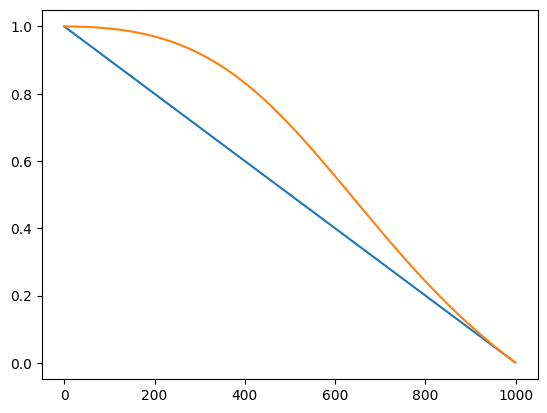

In [88]:
T = np.linspace(0, 999, 2000)
nt = T/1000
nt2 = (1 - nt)/np.sqrt(nt**2 + (1 - nt)**2)
plt.plot(T, 1-nt)
plt.plot(T, nt2, label = "nu")

In [79]:
nt**2 + (1 - nt)**2

array([1.      , 0.999001, 0.998003, ..., 0.996009, 0.997005, 0.998002],
      shape=(2000,))

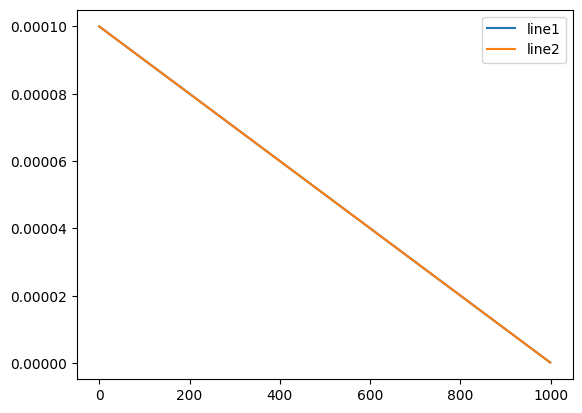

In [124]:
def get_lr2(ratio, lr_base = 1e-4, lr_min_ratio = 0.01):
    p = 1
    multiplier = (1 ** (1 / p) + ratio * (lr_min_ratio ** (1 / p) - 1 ** (1 / p))) ** p
    # print(multiplier)
    return multiplier * lr_base

l = np.linspace(0, 999, 1000)
ratio = l/1000
lr1 = get_lr2(ratio, 1e-4, lr_min_ratio = 1e-3)
lr2 = get_lr2(ratio, 1e-3, lr_min_ratio = 10)
plt.plot(l, lr1, label = "line1")
plt.plot(l, lr1,  label = "line2")
# plt.plot(l, lr1 - lr2)
plt.legend()

In [128]:
lr1

array([1.00000e-04, 9.99001e-05, 9.98002e-05, 9.97003e-05, 9.96004e-05,
       9.95005e-05, 9.94006e-05, 9.93007e-05, 9.92008e-05, 9.91009e-05,
       9.90010e-05, 9.89011e-05, 9.88012e-05, 9.87013e-05, 9.86014e-05,
       9.85015e-05, 9.84016e-05, 9.83017e-05, 9.82018e-05, 9.81019e-05,
       9.80020e-05, 9.79021e-05, 9.78022e-05, 9.77023e-05, 9.76024e-05,
       9.75025e-05, 9.74026e-05, 9.73027e-05, 9.72028e-05, 9.71029e-05,
       9.70030e-05, 9.69031e-05, 9.68032e-05, 9.67033e-05, 9.66034e-05,
       9.65035e-05, 9.64036e-05, 9.63037e-05, 9.62038e-05, 9.61039e-05,
       9.60040e-05, 9.59041e-05, 9.58042e-05, 9.57043e-05, 9.56044e-05,
       9.55045e-05, 9.54046e-05, 9.53047e-05, 9.52048e-05, 9.51049e-05,
       9.50050e-05, 9.49051e-05, 9.48052e-05, 9.47053e-05, 9.46054e-05,
       9.45055e-05, 9.44056e-05, 9.43057e-05, 9.42058e-05, 9.41059e-05,
       9.40060e-05, 9.39061e-05, 9.38062e-05, 9.37063e-05, 9.36064e-05,
       9.35065e-05, 9.34066e-05, 9.33067e-05, 9.32068e-05, 9.310

In [129]:
lr2

array([0.001   , 0.001009, 0.001018, 0.001027, 0.001036, 0.001045,
       0.001054, 0.001063, 0.001072, 0.001081, 0.00109 , 0.001099,
       0.001108, 0.001117, 0.001126, 0.001135, 0.001144, 0.001153,
       0.001162, 0.001171, 0.00118 , 0.001189, 0.001198, 0.001207,
       0.001216, 0.001225, 0.001234, 0.001243, 0.001252, 0.001261,
       0.00127 , 0.001279, 0.001288, 0.001297, 0.001306, 0.001315,
       0.001324, 0.001333, 0.001342, 0.001351, 0.00136 , 0.001369,
       0.001378, 0.001387, 0.001396, 0.001405, 0.001414, 0.001423,
       0.001432, 0.001441, 0.00145 , 0.001459, 0.001468, 0.001477,
       0.001486, 0.001495, 0.001504, 0.001513, 0.001522, 0.001531,
       0.00154 , 0.001549, 0.001558, 0.001567, 0.001576, 0.001585,
       0.001594, 0.001603, 0.001612, 0.001621, 0.00163 , 0.001639,
       0.001648, 0.001657, 0.001666, 0.001675, 0.001684, 0.001693,
       0.001702, 0.001711, 0.00172 , 0.001729, 0.001738, 0.001747,
       0.001756, 0.001765, 0.001774, 0.001783, 0.001792, 0.001